# References | Computer Vision

In [4]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

## Object Detection

Plotting the translation to/from box coordinates

In [ ]:
GRID_SIZE = 6
box = (0.25, 0.15, 0.40, 0.50)
x, y, w, h = box
# starting from normalized x, y (as if the image was 1x1)
# compute where the center should be, if now within that image
# we 1) move according to the grid, and 2) within each grid cell,
# again, we count proportionally, as if this cell was 1x1
cx, cy = (x + w / 2) * GRID_SIZE, (y + h / 2) * GRID_SIZE
print(f"{cx = :.3f}, {cy = :.3f}")

cx = 2.700, cy = 2.400


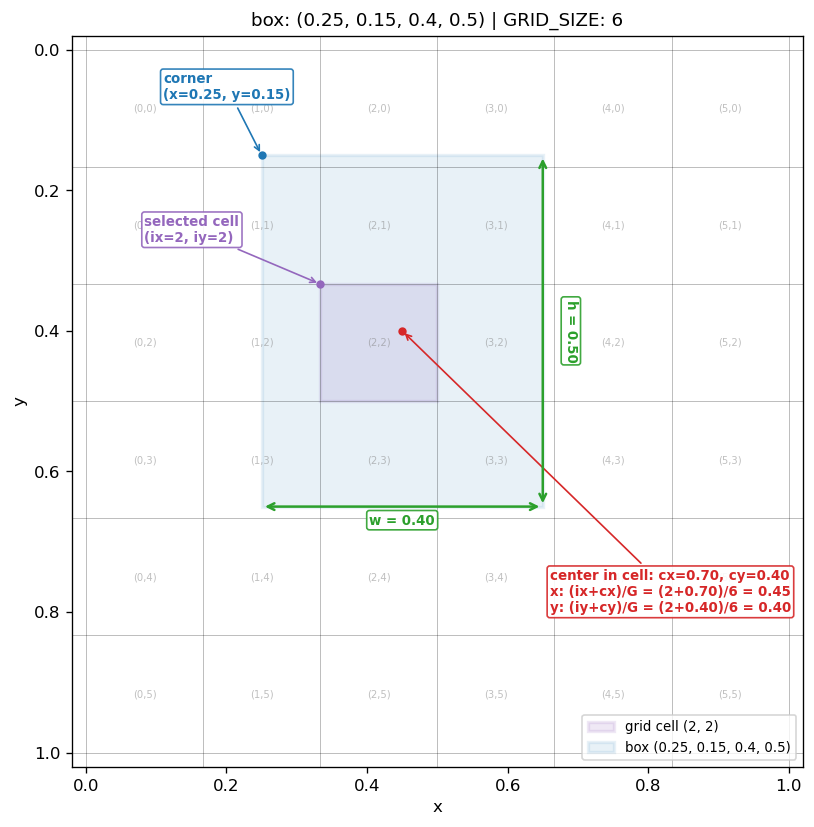

In [43]:
GRID_SIZE = 6

def to_grid(box):
    """
    Convert the normalised `x, y, w, h` to their grid-sized equivalent
    `(ix, iy)` will be ints, e.g. 2, 3
    `cx - ix, cy - iy are remainders within [0,1] boxes, e.g. (.23, .77)
    `w, h` remain untouched
    """
    x, y, w, h = box
    cx, cy = (x + w / 2) * GRID_SIZE, (y + h / 2) * GRID_SIZE
    ix, iy = int(cx), int(cy)
    # print(f"inside `to_grid`: {cx = :.3f} {cy = :.3f} ")
    return (ix, iy), (cx - ix, cy - iy, w, h)


box = (0.25, 0.15, 0.40, 0.50)
(ix, iy), grid_box = to_grid(box)
cx_off, cy_off, gw, gh = grid_box
x, y, w, h = box

fig, ax = plt.subplots(figsize=(7, 7), dpi=120)
ax.imshow(np.ones((10, 10, 3)), extent=[0, 1, 0, 1], aspect="auto")
ax.set_ylim(1.02, -0.02)
ax.set_xlim(-0.02, 1.02)
ax.set_aspect("equal")

# 1. Grid
cell_s = 1 / GRID_SIZE
for i in range(GRID_SIZE + 1):
    v = i * cell_s
    ax.axhline(v, color="black", lw=0.5, alpha=0.3)
    ax.axvline(v, color="black", lw=0.5, alpha=0.3)
for yi in range(GRID_SIZE):
    for xi in range(GRID_SIZE):
        ax.text((xi + 0.5) * cell_s, (yi + 0.5) * cell_s,
                f"({xi},{yi})", ha="center", va="center",
                fontsize=6, color="gray", alpha=0.5)

cell_rect = mpl.patches.Rectangle(
    (ix * cell_s, iy * cell_s), cell_s, cell_s,
    lw=2, ec="tab:purple", fc="tab:purple", alpha=0.15,
    label=f"grid cell ({ix}, {iy})")
ax.add_patch(cell_rect)

badge = dict(boxstyle="round,pad=0.2", fc="white", alpha=0.9)
cell_corner_x = ix * cell_s
cell_corner_y = iy * cell_s
ax.plot(cell_corner_x, cell_corner_y, "o", color="tab:purple", ms=4, zorder=5)
ax.annotate(
    f"selected cell\n(ix={ix}, iy={iy})",
    xy=(cell_corner_x, cell_corner_y),
    xytext=(cell_corner_x - 0.25, cell_corner_y - 0.06),
    fontsize=8, fontweight="bold", color="tab:purple",
    arrowprops=dict(arrowstyle="->", color="tab:purple"),
    bbox={**badge, "ec": "tab:purple"})

# 2. Box (x, y, w, h) with corner
box_rect = mpl.patches.Rectangle(
    (x, y), w, h, lw=2, ec="tab:blue", fc="tab:blue", alpha=0.1,
    label=f"box ({x}, {y}, {w}, {h})")
ax.add_patch(box_rect)

ax.plot(x, y, "o", color="tab:blue", ms=4, zorder=5)
ax.annotate(
    f"corner\n(x={x:.2f}, y={y:.2f})",
    xy=(x, y), xytext=(x - 0.14, y - 0.08),
    fontsize=8, fontweight="bold", color="tab:blue",
    arrowprops=dict(arrowstyle="->", color="tab:blue"),
    bbox={**badge, "ec": "tab:blue"})

# 3. Center of the box within the grid cell
center_x = (ix + cx_off) * cell_s
center_y = (iy + cy_off) * cell_s
ax.plot(center_x, center_y, "o", color="tab:red", ms=4, zorder=5)
ax.annotate(
    f"center in cell: cx={cx_off:.2f}, cy={cy_off:.2f}\n"
    f"x: (ix+cx)/G = ({ix}+{cx_off:.2f})/{GRID_SIZE} = {center_x:.2f}\n"
    f"y: (iy+cy)/G = ({iy}+{cy_off:.2f})/{GRID_SIZE} = {center_y:.2f}",
    xy=(center_x, center_y), xytext=(center_x + 0.21, center_y + 0.4),
    fontsize=8, fontweight="bold", color="tab:red",
    arrowprops=dict(arrowstyle="->", color="tab:red"),
    bbox={**badge, "ec": "tab:red"})

# 4. w and h on the box
ax.annotate(
    "", xy=(x + w, y + h), xytext=(x, y + h),
    arrowprops=dict(arrowstyle="<->", color="tab:green", lw=1.5))
ax.text(
    x + w / 2, y + h + 0.025, f"w = {w:.2f}",
    ha="center", fontsize=8, fontweight="bold", color="tab:green",
    bbox={**badge, "ec": "tab:green"})

ax.annotate(
    "", xy=(x + w, y + h), xytext=(x + w, y),
    arrowprops=dict(arrowstyle="<->", color="tab:green", lw=1.5))
ax.text(
    x + w + 0.03, y + h / 2, f"h = {h:.2f}",
    ha="left", va="center", fontsize=8, fontweight="bold",
    color="tab:green", rotation=-90,
    bbox={**badge, "ec": "tab:green"})


ax.legend(loc="lower right", fontsize=8)
ax.set_title(f"box: {box} | GRID_SIZE: {GRID_SIZE}", fontsize=11)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

Plotting the intersection area for two bounding boxes.

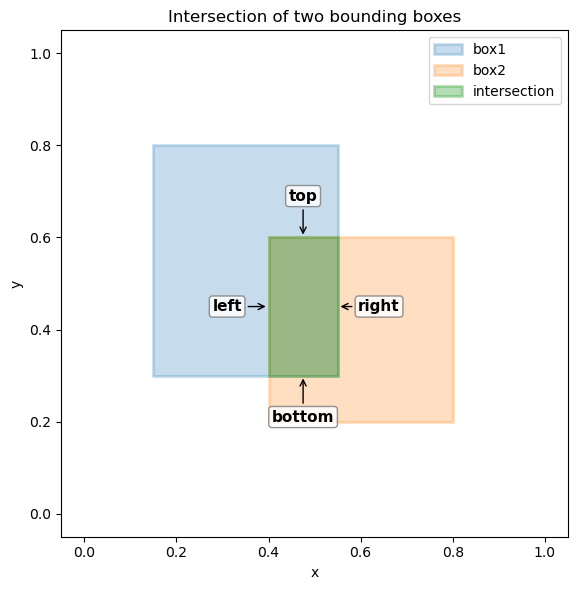

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.ones((100, 100, 3)), extent=[0, 1, 0, 1])

# Two dummy boxes: (center_x, center_y, width, height)
box1 = (0.35, 0.55, 0.4, 0.5)
box2 = (0.6, 0.4, 0.4, 0.4)

cx1, cy1, w1, h1 = box1
cx2, cy2, w2, h2 = box2

rect1 = mpl.patches.Rectangle((cx1 - w1/2, cy1 - h1/2), w1, h1,
                               linewidth=2, edgecolor="tab:blue", facecolor="tab:blue", alpha=0.25, label="box1")
rect2 = mpl.patches.Rectangle((cx2 - w2/2, cy2 - h2/2), w2, h2,
                               linewidth=2, edgecolor="tab:orange", facecolor="tab:orange", alpha=0.25, label="box2")
ax.add_patch(rect1)
ax.add_patch(rect2)

left   = max(cx1 - w1/2, cx2 - w2/2)
right  = min(cx1 + w1/2, cx2 + w2/2)
bottom = max(cy1 - h1/2, cy2 - h2/2)
top    = min(cy1 + h1/2, cy2 + h2/2)

inter = mpl.patches.Rectangle((left, bottom), right - left, top - bottom,
                                linewidth=2, edgecolor="tab:green", facecolor="tab:green", alpha=0.35, label="intersection")
ax.add_patch(inter)

style = dict(fontsize=11, fontweight="bold", ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.85))
offset = 0.03
ax.annotate("left",   xy=(left,  (bottom+top)/2), xytext=(left - offset*3, (bottom+top)/2),
            arrowprops=dict(arrowstyle="->", color="k"), **style)
ax.annotate("right",  xy=(right, (bottom+top)/2), xytext=(right + offset*3, (bottom+top)/2),
            arrowprops=dict(arrowstyle="->", color="k"), **style)
ax.annotate("bottom", xy=((left+right)/2, bottom), xytext=((left+right)/2, bottom - offset*3),
            arrowprops=dict(arrowstyle="->", color="k"), **style)
ax.annotate("top",    xy=((left+right)/2, top),    xytext=((left+right)/2, top + offset*3),
            arrowprops=dict(arrowstyle="->", color="k"), **style)

ax.set(xlim=(-0.05, 1.05), ylim=(-0.05, 1.05), xlabel="x", ylabel="y")
ax.set_aspect("equal")
ax.legend(loc="upper right")
ax.set_title("Intersection of two bounding boxes")
plt.tight_layout()
plt.show()